In [1]:
# ================================================================
# LAB 4: Compare RNN vs LSTM vs GRU Performance
# Dataset: IMDB Sentiment Classification
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# ----------------------------------------------------------------
# 1. HYPERPARAMETERS
# ----------------------------------------------------------------
VOCAB_SIZE   = 10000
MAX_LEN      = 200
EMBED_DIM    = 64
HIDDEN_UNITS = 64
DROPOUT      = 0.3
BATCH_SIZE   = 128
EPOCHS       = 10

In [3]:
# 2. LOAD AND PREPROCESS DATA
# ----------------------------------------------------------------
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post')

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000, 200)
Test shape : (25000, 200)


In [4]:
# 3. MODEL BUILDER FUNCTION
# ----------------------------------------------------------------
def build_model(cell_type='RNN'):
    model = Sequential()
    model.add(Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN))

    if cell_type == 'RNN':
        model.add(SimpleRNN(HIDDEN_UNITS, return_sequences=False))
    elif cell_type == 'LSTM':
        model.add(LSTM(HIDDEN_UNITS, return_sequences=False))
    elif cell_type == 'GRU':
        model.add(GRU(HIDDEN_UNITS, return_sequences=False))

    model.add(Dropout(DROPOUT))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [5]:
# 4. TRAIN ALL THREE MODELS
# ----------------------------------------------------------------
results = {}
histories = {}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

for cell in ['RNN', 'LSTM', 'GRU']:
    print(f"\n{'='*40}")
    print(f"  Training {cell} model...")
    print(f"{'='*40}")

    model = build_model(cell)

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    elapsed = time.time() - start

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results[cell] = {
        'test_accuracy': acc,
        'test_loss': loss,
        'train_time_sec': round(elapsed, 2),
        'epochs_run': len(history.history['loss'])
    }
    histories[cell] = history

    print(f"  {cell} → Test Accuracy: {acc:.4f} | Time: {elapsed:.1f}s")


  Training RNN model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5144 - loss: 0.6940 - val_accuracy: 0.5394 - val_loss: 0.6843
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6163 - loss: 0.6464 - val_accuracy: 0.5356 - val_loss: 0.6795
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6920 - loss: 0.5543 - val_accuracy: 0.5422 - val_loss: 0.7327
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7362 - loss: 0.4507 - val_accuracy: 0.5332 - val_loss: 0.7822
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7706 - loss: 0.3819 - val_accuracy: 0.5354 - val_loss: 0.8541
  RNN → Test Accuracy: 0.5456 | Time: 20.3s

  Training LSTM model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5459 - loss: 0.6813 - val_accuracy: 0.5882 - val_loss: 0.6507
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6259 - loss: 0.6417 - val_accuracy: 0.6362 - val_loss: 0.6203
Ep

In [6]:
# 5. PRINT COMPARISON TABLE
# ----------------------------------------------------------------
print("\n" + "="*55)
print(f"{'Model':<8} {'Accuracy':>10} {'Loss':>10} {'Time(s)':>10} {'Epochs':>8}")
print("="*55)
for cell, r in results.items():
    print(f"{cell:<8} {r['test_accuracy']:>10.4f} {r['test_loss']:>10.4f} "
          f"{r['train_time_sec']:>10.2f} {r['epochs_run']:>8}")
print("="*55)



Model      Accuracy       Loss    Time(s)   Epochs
RNN          0.5456     0.6779      20.27        5
LSTM         0.8216     0.4406      20.79        7
GRU          0.8759     0.3093      19.56        7


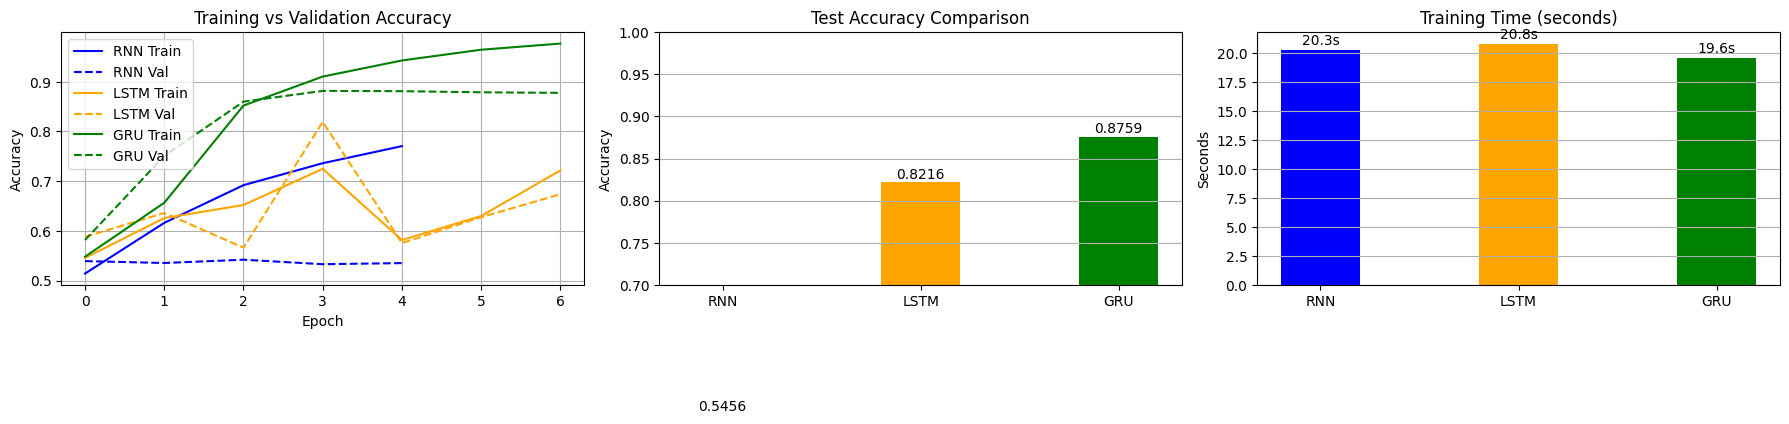


Plot saved as lab4_comparison.png


In [7]:
# 6. PLOT RESULTS
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'RNN': 'blue', 'LSTM': 'orange', 'GRU': 'green'}

# --- Plot 1: Training Accuracy Curves ---
ax = axes[0]
for cell, h in histories.items():
    ax.plot(h.history['accuracy'], label=f'{cell} Train', color=colors[cell])
    ax.plot(h.history['val_accuracy'], label=f'{cell} Val', color=colors[cell], linestyle='--')
ax.set_title('Training vs Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True)

# --- Plot 2: Test Accuracy Bar Chart ---
ax = axes[1]
names = list(results.keys())
accs  = [results[c]['test_accuracy'] for c in names]
bars  = ax.bar(names, accs, color=[colors[c] for c in names], width=0.4)
ax.set_title('Test Accuracy Comparison')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.0)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', fontsize=10)
ax.grid(axis='y')

# --- Plot 3: Training Time Bar Chart ---
ax = axes[2]
times = [results[c]['train_time_sec'] for c in names]
bars  = ax.bar(names, times, color=[colors[c] for c in names], width=0.4)
ax.set_title('Training Time (seconds)')
ax.set_ylabel('Seconds')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', fontsize=10)
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('lab4_comparison.png', dpi=150)
plt.show()
print("\nPlot saved as lab4_comparison.png")
